# Preprocesamiento de Datos

## 3.- Datos Inútiles (o poco útiles)

### 3.1 Atributos completamente concentrados

In [ ]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Descargar y cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df = pd.read_csv(url)

# Creamos un nuevo atributo 'year' con el valor 1987
df['year'] = 1987

# Verificar el DataFrame con la nueva columna
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,cars,carname,year
0,4.582576,6,160.0,110,3.90,2.620,16.46,0,1,4,4,1,Mazda RX4,Mazda RX4,1987
1,4.582576,6,160.0,110,3.90,2.875,17.02,0,1,4,4,1,Mazda RX4 Wag,Mazda RX4 Wag,1987
2,4.774935,4,108.0,93,3.85,2.320,18.61,1,1,4,1,1,Datsun 710,Datsun 710,1987
3,4.626013,6,258.0,110,3.08,3.215,19.44,1,0,3,1,1,Hornet 4 Drive,Hornet 4 Drive,1987
4,4.324350,8,360.0,175,3.15,3.440,17.02,0,0,3,2,1,Hornet Sportabout,Hornet Sportabout,1987


In [ ]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,year
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000,32.000000,32.0
mean,4.434770,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125,0.687500,1987.0
std,0.661137,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152,0.470929,0.0
min,3.224903,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000,0.000000,1987.0
25%,3.927432,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000,0.000000,1987.0
50%,4.381780,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000,1.000000,1987.0
75%,4.774935,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000,1.000000,1987.0
max,5.822371,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000,1.000000,1987.0


In [ ]:
# Eliminar la columna 'carname' antes de aplicar VarianceThreshold, ya que es categórica
df_numeric = df.drop(columns=['carname','cars'])

# Aplicar VarianceThreshold para eliminar la columna con varianza cero
selector = VarianceThreshold(threshold=0.0)
df_reduced = selector.fit_transform(df_numeric)

# Convertir el resultado de nuevo a un DataFrame
df_reduced = pd.DataFrame(df_reduced, columns=df_numeric.columns[selector.get_support()])

# Verificar el DataFrame después de eliminar la columna 'year'
print("\nDataFrame después de aplicar VarianceThreshold:")
df_reduced.head()


DataFrame después de aplicar VarianceThreshold:


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast
0,4.582576,6.0,160.0,110.0,3.90,2.620,16.46,0.0,1.0,4.0,4.0,1.0
1,4.582576,6.0,160.0,110.0,3.90,2.875,17.02,0.0,1.0,4.0,4.0,1.0
2,4.774935,4.0,108.0,93.0,3.85,2.320,18.61,1.0,1.0,4.0,1.0,1.0
3,4.626013,6.0,258.0,110.0,3.08,3.215,19.44,1.0,0.0,3.0,1.0,1.0
4,4.324350,8.0,360.0,175.0,3.15,3.440,17.02,0.0,0.0,3.0,2.0,1.0


### 3.2 OUTLIERS

#### Unidimensionales

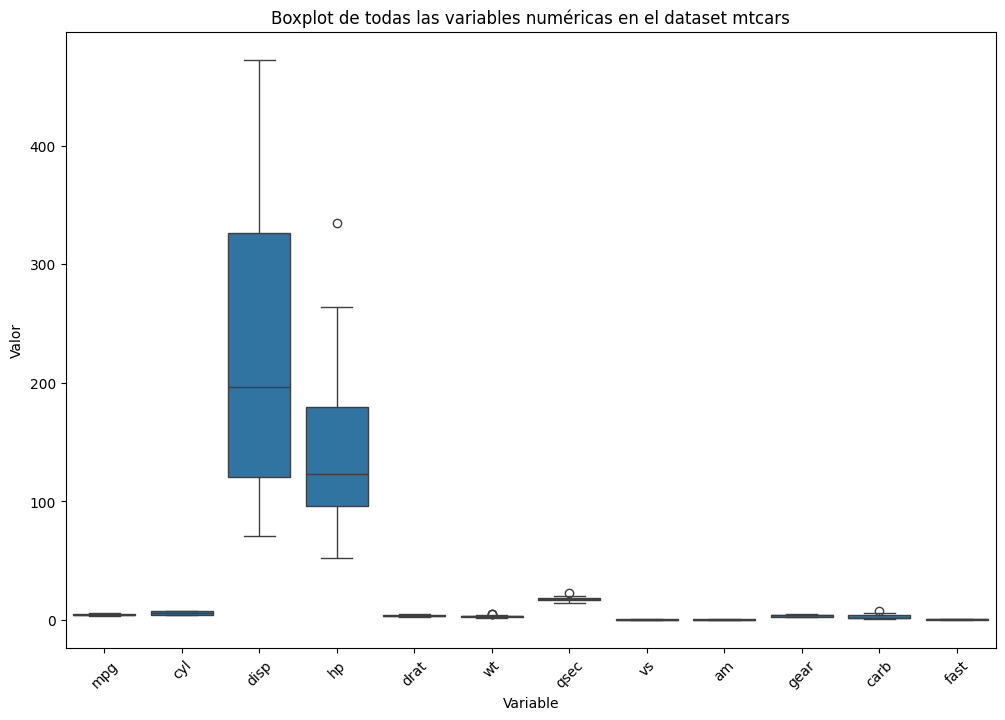

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Descargar y cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df = pd.read_csv(url)

# Eliminar la columna 'carname' ya que es categórica y no se incluye en el boxplot
df_numeric = df.drop(columns=['carname','cars'])

# pivotear el dataframe
df_melted = df_numeric.melt(var_name='Variable', value_name='Valor')

# Crear un boxplot para todas las variables numéricas usando seaborn
plt.figure(figsize=(12, 8))
sns.boxplot(x='Variable', y='Valor', data=df_melted)
plt.title('Boxplot de todas las variables numéricas en el dataset mtcars')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df[df['hp']>=300]

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,cars,carname
30,3.872983,8,301.0,335,3.54,3.57,14.6,0,1,5,8,0,Maserati Bora,Maserati Bora


Sacarias esa observación del Dataset?

#### Outliers multidimensionales

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Descargar y cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df = pd.read_csv(url)

# Eliminar la columna 'carname' ya que es categórica
df_numeric = df.drop(columns=['carname','cars'])

# Aplicar Isolation Forest para detectar outliers
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['outlier'] = iso_forest.fit_predict(df_numeric)

# Los outliers son marcados con -1, mientras que los puntos normales con 1
outliers = df[df['outlier'] == -1]
non_outliers = df[df['outlier'] == 1]

# Mostrar los outliers detectados
print("\nOutliers detectados:\n")
outliers


Outliers detectados:



,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,fast,cars,carname,outlier
18,5.513620,4,75.7,52,4.93,1.615,18.52,1,1,4,2,1,Honda Civic,Honda Civic,-1
28,3.974921,8,351.0,264,4.22,3.170,14.50,0,1,5,4,0,Ford Pantera L,Ford Pantera L,-1
29,4.438468,6,145.0,175,3.62,2.770,15.50,0,1,5,6,1,Ferrari Dino,Ferrari Dino,-1
30,3.872983,8,301.0,335,3.54,3.570,14.60,0,1,5,8,0,Maserati Bora,Maserati Bora,-1


### 3.4 Multicolinealidad

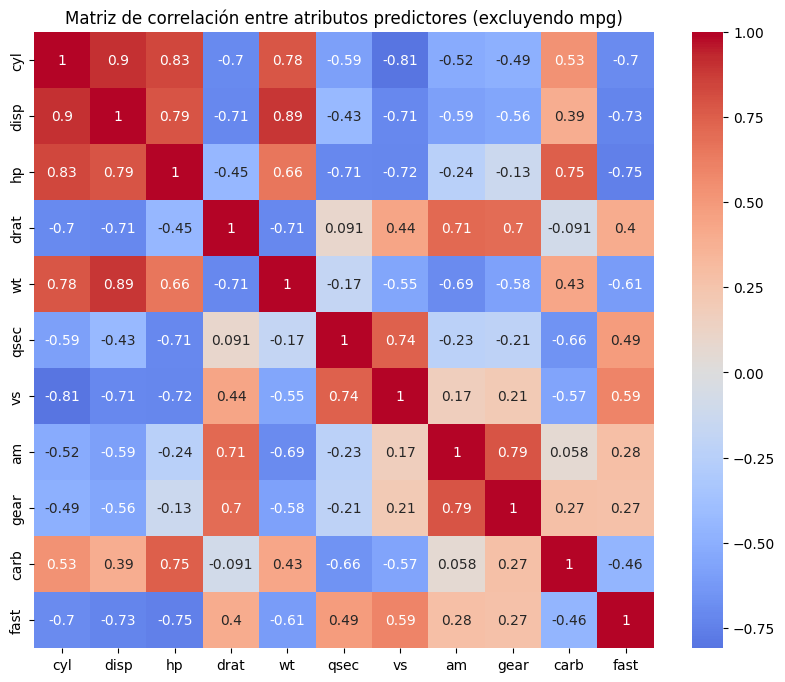

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Descargar y cargar el dataset mtcars
url = "https://raw.githubusercontent.com/selva86/datasets/master/mtcars.csv"
df = pd.read_csv(url)

# Eliminar la columna 'carname' ya que es categórica
df_numeric = df.drop(columns=['cars','carname', 'mpg'])  # Excluir también la columna 'mpg'

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación usando un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre atributos predictores (excluyendo mpg)')
plt.show()

In [ ]:
#Eliminamos los atributos con mayor correlación (dejamos 1)
df = df.drop(['cyl','wt'],axis=1)